# Pelatihan Model AI e-Sign (Prophet)


In [1]:
!pip install prophet statsmodels scikit-learn matplotlib

## 0. Generate Synthetic Data

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os

def generate_synthetic_data(num_days=365):
    current_dir = '/content'

    # Konfigurasi beban per pegawai
    pegawai_configs = {
        '1a2394378ddbb186f6f622e8b3c872ee6872623f': {'base_nodin': 0, 'base_spt': 0, 'desc': 'staff'},
        '54a8b8362ebcb16af08c8acf33a2d8d5f335cf5e': {'base_nodin': 3, 'base_spt': 3, 'desc': 'pptk'},
        'ae914d89870f2450ca4c6ca9f34e3080317546e5': {'base_nodin': 5, 'base_spt': 8, 'desc': 'kabid'},
        '8018dcd81ff171aa9629c08d95422c20e45e307b': {'base_nodin': 12, 'base_spt': 15, 'desc': 'asekda'},
        'a4adb04d8392abc79d52ea247fabd8348b97a78a': {'base_nodin': 20, 'base_spt': 25, 'desc': 'sekda'},
    }

    end_date = datetime.now().date()
    start_date = end_date - timedelta(days=num_days - 1)
    date_rng = pd.date_range(start=start_date, end=end_date, freq='D')

    np.random.seed(42)

    for pegawai_id, config in pegawai_configs.items():
        data = []
        base_nodin = config['base_nodin']
        base_spt = config['base_spt']

        for dt in date_rng:
            date_str = dt.strftime('%Y-%m-%d')
            day_of_week = dt.weekday()
            month = dt.month

            if base_nodin == 0 and base_spt == 0:
                nodin = 0
                spt = 0
            else:
                if day_of_week in [0, 1, 2]: # Senin-Rabu
                    multiplier = np.random.uniform(1.0, 1.3)
                elif day_of_week in [3, 4]: # Kamis-Jumat
                    multiplier = np.random.uniform(0.7, 1.0)
                else: # Sabtu-Minggu libur
                    multiplier = np.random.uniform(0.0, 0.1)

                if month in [11, 12]:
                    multiplier *= 1.3
                elif month in [6, 7]:
                    multiplier *= 1.2

                nodin = int(base_nodin * multiplier) + np.random.randint(-2, 3)
                spt = int(base_spt * multiplier) + np.random.randint(-2, 3)

                nodin = max(0, nodin)
                spt = max(0, spt)

            data.append({
                'tanggal': date_str,
                'nodin': nodin,
                'spt': spt,
                'total': nodin + spt
            })

        df = pd.DataFrame(data)
        final_csv_path = os.path.join(current_dir, f'historical_data_pegawai_{pegawai_id}.csv')
        df.to_csv(final_csv_path, index=False)
        print(f"Berhasil membuat dataset untuk {config['desc']} -> {final_csv_path}")

# Jalankan generator data
generate_synthetic_data(365)


Berhasil membuat dataset untuk staff -> /content/historical_data_pegawai_1a2394378ddbb186f6f622e8b3c872ee6872623f.csv
Berhasil membuat dataset untuk pptk -> /content/historical_data_pegawai_54a8b8362ebcb16af08c8acf33a2d8d5f335cf5e.csv
Berhasil membuat dataset untuk kabid -> /content/historical_data_pegawai_ae914d89870f2450ca4c6ca9f34e3080317546e5.csv
Berhasil membuat dataset untuk asekda -> /content/historical_data_pegawai_8018dcd81ff171aa9629c08d95422c20e45e307b.csv
Berhasil membuat dataset untuk sekda -> /content/historical_data_pegawai_a4adb04d8392abc79d52ea247fabd8348b97a78a.csv


## 1. Import Library & Fungsi Pelatihan

In [3]:
import pandas as pd
from prophet import Prophet
import json
from prophet.serialize import model_to_json
import os

def train_and_save_models():
    pegawai_ids = [
        '1a2394378ddbb186f6f622e8b3c872ee6872623f',
        '54a8b8362ebcb16af08c8acf33a2d8d5f335cf5e',
        'ae914d89870f2450ca4c6ca9f34e3080317546e5',
        '8018dcd81ff171aa9629c08d95422c20e45e307b',
        'a4adb04d8392abc79d52ea247fabd8348b97a78a',
    ]

    current_dir = '/content'

    for pegawai_id in pegawai_ids:
        data_path = os.path.join(current_dir, f'historical_data_pegawai_{pegawai_id}.csv')
        if not os.path.exists(data_path):
            print(f"Data untuk pegawai {pegawai_id} tidak ditemukan. Melewati...")
            continue

        df = pd.read_csv(data_path)

        # --- TRAINING MODEL NODIN ---
        print(f"Melatih model Nodin untuk Pegawai {pegawai_id}...")
        df_nodin = df[['tanggal', 'nodin']].rename(columns={'tanggal': 'ds', 'nodin': 'y'})
        model_nodin = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
        model_nodin.fit(df_nodin)

        with open(os.path.join(current_dir, f'model_nodin_pegawai_{pegawai_id}.json'), 'w') as f:
            json.dump(model_to_json(model_nodin), f)

        # --- TRAINING MODEL SPT ---
        print(f"Melatih model SPT untuk Pegawai {pegawai_id}...")
        df_spt = df[['tanggal', 'spt']].rename(columns={'tanggal': 'ds', 'spt': 'y'})
        model_spt = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
        model_spt.fit(df_spt)

        with open(os.path.join(current_dir, f'model_spt_pegawai_{pegawai_id}.json'), 'w') as f:
            json.dump(model_to_json(model_spt), f)

    print("Model AI (Prophet) berhasil dilatih dan disimpan! Silakan download file .json yang dihasilkan dari folder /content di menu sebelah kiri Colab.")


In [4]:
# Eksekusi Pelatihan
train_and_save_models()

Melatih model Nodin untuk Pegawai 1a2394378ddbb186f6f622e8b3c872ee6872623f...
Melatih model SPT untuk Pegawai 1a2394378ddbb186f6f622e8b3c872ee6872623f...
Melatih model Nodin untuk Pegawai 54a8b8362ebcb16af08c8acf33a2d8d5f335cf5e...
Melatih model SPT untuk Pegawai 54a8b8362ebcb16af08c8acf33a2d8d5f335cf5e...
Melatih model Nodin untuk Pegawai ae914d89870f2450ca4c6ca9f34e3080317546e5...
Melatih model SPT untuk Pegawai ae914d89870f2450ca4c6ca9f34e3080317546e5...
Melatih model Nodin untuk Pegawai 8018dcd81ff171aa9629c08d95422c20e45e307b...
Melatih model SPT untuk Pegawai 8018dcd81ff171aa9629c08d95422c20e45e307b...
Melatih model Nodin untuk Pegawai a4adb04d8392abc79d52ea247fabd8348b97a78a...
Melatih model SPT untuk Pegawai a4adb04d8392abc79d52ea247fabd8348b97a78a...
Model AI (Prophet) berhasil dilatih dan disimpan! Silakan download file .json yang dihasilkan dari folder /content di menu sebelah kiri Colab.


## 2. Evaluasi Model (Perbandingan MAE & RMSE)

Melatih model Prophet...
Melatih model ARIMA...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Melatih model Exponential Smoothing...

--- HASIL EVALUASI MODEL ---
Model                     | MAE        | RMSE
--------------------------------------------------
Prophet                   | 0.0000     | 0.0000
ARIMA                     | 0.0000     | 0.0000
Exponential Smoothing     | 0.0000     | 0.0000
Naive Baseline            | 0.0000     | 0.0000


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1380: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse / self.nobs) + k * 2
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1387: RuntimeWarning: divide by zero encountered in log
  bic = self.nobs * np.log(sse / self.nobs) + k * np.log(self.nobs)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1380: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse / self.nobs) + k * 2
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1387: RuntimeWarning: divide by zero encountered in log
  bic = self.nobs * np.log(sse / self.nobs) + k * np.log(self.nobs)


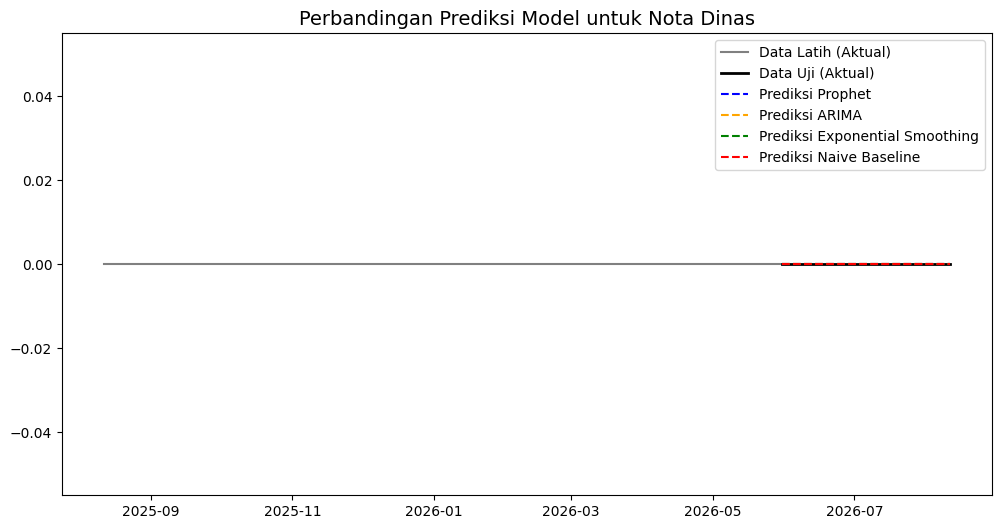

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_models():
    pegawai_id = '1a2394378ddbb186f6f622e8b3c872ee6872623f'
    data_path = f'/content/historical_data_pegawai_{pegawai_id}.csv'

    if not os.path.exists(data_path):
        print("Jalankan cell generate data terlebih dahulu!")
        return

    df = pd.read_csv(data_path)
    df_eval = df[['tanggal', 'nodin']].rename(columns={'tanggal': 'ds', 'nodin': 'y'})
    df_eval['ds'] = pd.to_datetime(df_eval['ds'])
    df_eval = df_eval.sort_values('ds')

    train_size = int(len(df_eval) * 0.8)
    train_df = df_eval.iloc[:train_size].copy()
    test_df = df_eval.iloc[train_size:].copy()

    predictions = pd.DataFrame({'ds': test_df['ds'], 'Aktual': test_df['y']})

    print("Melatih model Prophet...")
    model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model_prophet.fit(train_df)
    future = model_prophet.make_future_dataframe(periods=len(test_df))
    pred_prophet = model_prophet.predict(future)['yhat'].iloc[-len(test_df):].values
    predictions['Prophet'] = np.maximum(0, pred_prophet)

    print("Melatih model ARIMA...")
    try:
        model_arima_fit = ARIMA(train_df['y'].values, order=(5,1,0)).fit()
        predictions['ARIMA'] = np.maximum(0, model_arima_fit.forecast(steps=len(test_df)))
    except:
        predictions['ARIMA'] = 0

    print("Melatih model Exponential Smoothing...")
    try:
        model_hw_fit = ExponentialSmoothing(train_df['y'].values, trend='add').fit()
        predictions['Exponential Smoothing'] = np.maximum(0, model_hw_fit.forecast(steps=len(test_df)))
    except:
        predictions['Exponential Smoothing'] = 0

    predictions['Naive Baseline'] = [train_df['y'].iloc[-1]] * len(test_df)

    models_to_eval = ['Prophet', 'ARIMA', 'Exponential Smoothing', 'Naive Baseline']

    print("\n--- HASIL EVALUASI MODEL ---")
    print(f"{'Model':<25} | {'MAE':<10} | {'RMSE'}")
    print("-" * 50)
    for m in models_to_eval:
        mae = mean_absolute_error(predictions['Aktual'], predictions[m])
        rmse = np.sqrt(mean_squared_error(predictions['Aktual'], predictions[m]))
        print(f"{m:<25} | {mae:<10.4f} | {rmse:.4f}")

    plt.figure(figsize=(12, 6))
    plt.plot(train_df['ds'], train_df['y'], label='Data Latih (Aktual)', color='gray')
    plt.plot(predictions['ds'], predictions['Aktual'], label='Data Uji (Aktual)', color='black', linewidth=2)
    colors = ['blue', 'orange', 'green', 'red']
    for idx, m in enumerate(models_to_eval):
        plt.plot(predictions['ds'], predictions[m], label=f'Prediksi {m}', color=colors[idx], linestyle='--')
    plt.title(f'Perbandingan Prediksi Model untuk Nota Dinas', fontsize=14)
    plt.legend()
    plt.show()

evaluate_models()

Melatih model Prophet...
Melatih model ARIMA...
Melatih model Exponential Smoothing...

--- HASIL EVALUASI MODEL ---
Model                     | MAE        | RMSE
--------------------------------------------------
Prophet                   | 1.5470     | 2.0186
ARIMA                     | 1.7660     | 2.1095
Exponential Smoothing     | 1.7143     | 2.0566
Naive Baseline            | 1.6712     | 2.0204


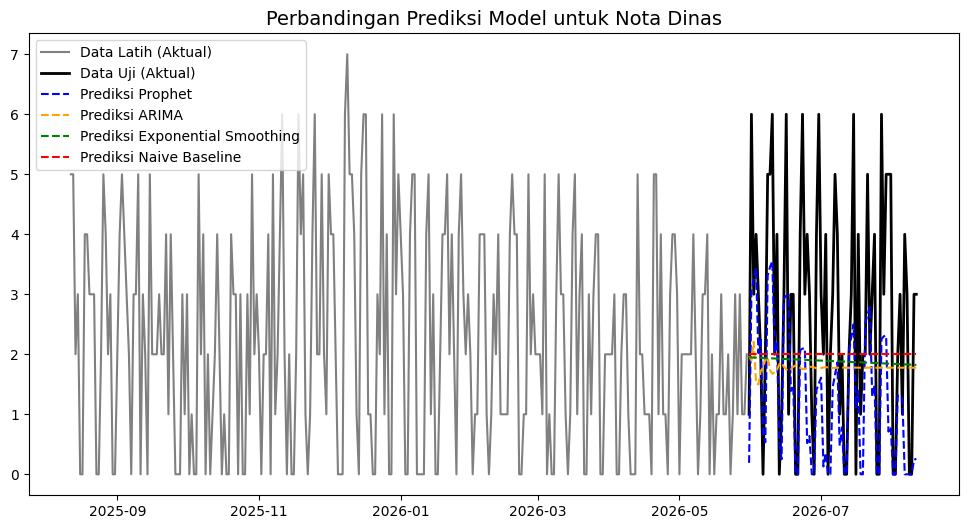

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_models():
    pegawai_id = '54a8b8362ebcb16af08c8acf33a2d8d5f335cf5e'
    data_path = f'/content/historical_data_pegawai_{pegawai_id}.csv'

    if not os.path.exists(data_path):
        print("Jalankan cell generate data terlebih dahulu!")
        return

    df = pd.read_csv(data_path)
    df_eval = df[['tanggal', 'nodin']].rename(columns={'tanggal': 'ds', 'nodin': 'y'})
    df_eval['ds'] = pd.to_datetime(df_eval['ds'])
    df_eval = df_eval.sort_values('ds')

    train_size = int(len(df_eval) * 0.8)
    train_df = df_eval.iloc[:train_size].copy()
    test_df = df_eval.iloc[train_size:].copy()

    predictions = pd.DataFrame({'ds': test_df['ds'], 'Aktual': test_df['y']})

    print("Melatih model Prophet...")
    model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model_prophet.fit(train_df)
    future = model_prophet.make_future_dataframe(periods=len(test_df))
    pred_prophet = model_prophet.predict(future)['yhat'].iloc[-len(test_df):].values
    predictions['Prophet'] = np.maximum(0, pred_prophet)

    print("Melatih model ARIMA...")
    try:
        model_arima_fit = ARIMA(train_df['y'].values, order=(5,1,0)).fit()
        predictions['ARIMA'] = np.maximum(0, model_arima_fit.forecast(steps=len(test_df)))
    except:
        predictions['ARIMA'] = 0

    print("Melatih model Exponential Smoothing...")
    try:
        model_hw_fit = ExponentialSmoothing(train_df['y'].values, trend='add').fit()
        predictions['Exponential Smoothing'] = np.maximum(0, model_hw_fit.forecast(steps=len(test_df)))
    except:
        predictions['Exponential Smoothing'] = 0

    predictions['Naive Baseline'] = [train_df['y'].iloc[-1]] * len(test_df)

    models_to_eval = ['Prophet', 'ARIMA', 'Exponential Smoothing', 'Naive Baseline']

    print("\n--- HASIL EVALUASI MODEL ---")
    print(f"{'Model':<25} | {'MAE':<10} | {'RMSE'}")
    print("-" * 50)
    for m in models_to_eval:
        mae = mean_absolute_error(predictions['Aktual'], predictions[m])
        rmse = np.sqrt(mean_squared_error(predictions['Aktual'], predictions[m]))
        print(f"{m:<25} | {mae:<10.4f} | {rmse:.4f}")

    plt.figure(figsize=(12, 6))
    plt.plot(train_df['ds'], train_df['y'], label='Data Latih (Aktual)', color='gray')
    plt.plot(predictions['ds'], predictions['Aktual'], label='Data Uji (Aktual)', color='black', linewidth=2)
    colors = ['blue', 'orange', 'green', 'red']
    for idx, m in enumerate(models_to_eval):
        plt.plot(predictions['ds'], predictions[m], label=f'Prediksi {m}', color=colors[idx], linestyle='--')
    plt.title(f'Perbandingan Prediksi Model untuk Nota Dinas', fontsize=14)
    plt.legend()
    plt.show()

evaluate_models()

Melatih model Prophet...
Melatih model ARIMA...
Melatih model Exponential Smoothing...

--- HASIL EVALUASI MODEL ---
Model                     | MAE        | RMSE
--------------------------------------------------
Prophet                   | 1.8230     | 2.3870
ARIMA                     | 2.5756     | 2.9453
Exponential Smoothing     | 2.6494     | 3.0008
Naive Baseline            | 3.6438     | 4.3542


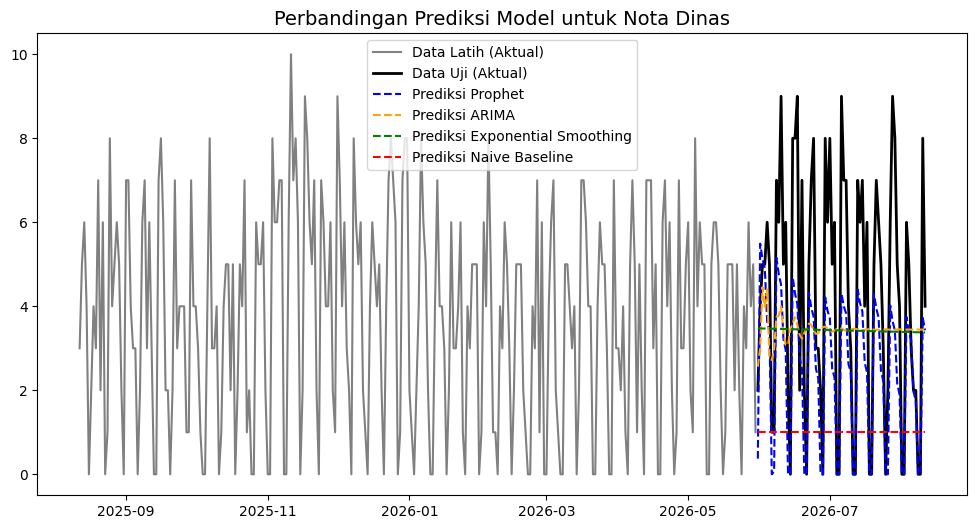

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_models():
    pegawai_id = 'ae914d89870f2450ca4c6ca9f34e3080317546e5'
    data_path = f'/content/historical_data_pegawai_{pegawai_id}.csv'

    if not os.path.exists(data_path):
        print("Jalankan cell generate data terlebih dahulu!")
        return

    df = pd.read_csv(data_path)
    df_eval = df[['tanggal', 'nodin']].rename(columns={'tanggal': 'ds', 'nodin': 'y'})
    df_eval['ds'] = pd.to_datetime(df_eval['ds'])
    df_eval = df_eval.sort_values('ds')

    train_size = int(len(df_eval) * 0.8)
    train_df = df_eval.iloc[:train_size].copy()
    test_df = df_eval.iloc[train_size:].copy()

    predictions = pd.DataFrame({'ds': test_df['ds'], 'Aktual': test_df['y']})

    print("Melatih model Prophet...")
    model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model_prophet.fit(train_df)
    future = model_prophet.make_future_dataframe(periods=len(test_df))
    pred_prophet = model_prophet.predict(future)['yhat'].iloc[-len(test_df):].values
    predictions['Prophet'] = np.maximum(0, pred_prophet)

    print("Melatih model ARIMA...")
    try:
        model_arima_fit = ARIMA(train_df['y'].values, order=(5,1,0)).fit()
        predictions['ARIMA'] = np.maximum(0, model_arima_fit.forecast(steps=len(test_df)))
    except:
        predictions['ARIMA'] = 0

    print("Melatih model Exponential Smoothing...")
    try:
        model_hw_fit = ExponentialSmoothing(train_df['y'].values, trend='add').fit()
        predictions['Exponential Smoothing'] = np.maximum(0, model_hw_fit.forecast(steps=len(test_df)))
    except:
        predictions['Exponential Smoothing'] = 0

    predictions['Naive Baseline'] = [train_df['y'].iloc[-1]] * len(test_df)

    models_to_eval = ['Prophet', 'ARIMA', 'Exponential Smoothing', 'Naive Baseline']

    print("\n--- HASIL EVALUASI MODEL ---")
    print(f"{'Model':<25} | {'MAE':<10} | {'RMSE'}")
    print("-" * 50)
    for m in models_to_eval:
        mae = mean_absolute_error(predictions['Aktual'], predictions[m])
        rmse = np.sqrt(mean_squared_error(predictions['Aktual'], predictions[m]))
        print(f"{m:<25} | {mae:<10.4f} | {rmse:.4f}")

    plt.figure(figsize=(12, 6))
    plt.plot(train_df['ds'], train_df['y'], label='Data Latih (Aktual)', color='gray')
    plt.plot(predictions['ds'], predictions['Aktual'], label='Data Uji (Aktual)', color='black', linewidth=2)
    colors = ['blue', 'orange', 'green', 'red']
    for idx, m in enumerate(models_to_eval):
        plt.plot(predictions['ds'], predictions[m], label=f'Prediksi {m}', color=colors[idx], linestyle='--')
    plt.title(f'Perbandingan Prediksi Model untuk Nota Dinas', fontsize=14)
    plt.legend()
    plt.show()

evaluate_models()

Melatih model Prophet...
Melatih model ARIMA...
Melatih model Exponential Smoothing...

--- HASIL EVALUASI MODEL ---
Model                     | MAE        | RMSE
--------------------------------------------------
Prophet                   | 7.2768     | 8.9213
ARIMA                     | 5.7284     | 6.3091
Exponential Smoothing     | 6.2845     | 6.8763
Naive Baseline            | 10.4247    | 12.3660


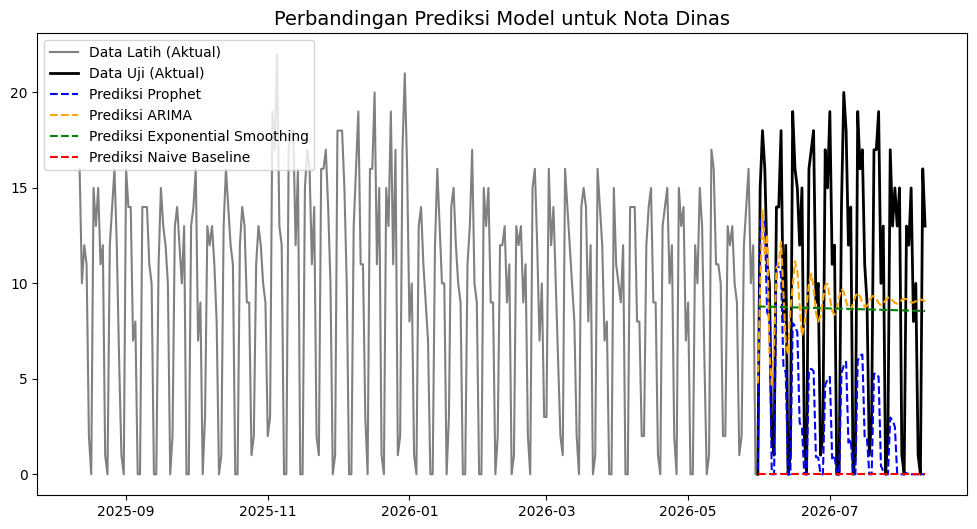

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_models():
    pegawai_id = '8018dcd81ff171aa9629c08d95422c20e45e307b'
    data_path = f'/content/historical_data_pegawai_{pegawai_id}.csv'

    if not os.path.exists(data_path):
        print("Jalankan cell generate data terlebih dahulu!")
        return

    df = pd.read_csv(data_path)
    df_eval = df[['tanggal', 'nodin']].rename(columns={'tanggal': 'ds', 'nodin': 'y'})
    df_eval['ds'] = pd.to_datetime(df_eval['ds'])
    df_eval = df_eval.sort_values('ds')

    train_size = int(len(df_eval) * 0.8)
    train_df = df_eval.iloc[:train_size].copy()
    test_df = df_eval.iloc[train_size:].copy()

    predictions = pd.DataFrame({'ds': test_df['ds'], 'Aktual': test_df['y']})

    print("Melatih model Prophet...")
    model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model_prophet.fit(train_df)
    future = model_prophet.make_future_dataframe(periods=len(test_df))
    pred_prophet = model_prophet.predict(future)['yhat'].iloc[-len(test_df):].values
    predictions['Prophet'] = np.maximum(0, pred_prophet)

    print("Melatih model ARIMA...")
    try:
        model_arima_fit = ARIMA(train_df['y'].values, order=(5,1,0)).fit()
        predictions['ARIMA'] = np.maximum(0, model_arima_fit.forecast(steps=len(test_df)))
    except:
        predictions['ARIMA'] = 0

    print("Melatih model Exponential Smoothing...")
    try:
        model_hw_fit = ExponentialSmoothing(train_df['y'].values, trend='add').fit()
        predictions['Exponential Smoothing'] = np.maximum(0, model_hw_fit.forecast(steps=len(test_df)))
    except:
        predictions['Exponential Smoothing'] = 0

    predictions['Naive Baseline'] = [train_df['y'].iloc[-1]] * len(test_df)

    models_to_eval = ['Prophet', 'ARIMA', 'Exponential Smoothing', 'Naive Baseline']

    print("\n--- HASIL EVALUASI MODEL ---")
    print(f"{'Model':<25} | {'MAE':<10} | {'RMSE'}")
    print("-" * 50)
    for m in models_to_eval:
        mae = mean_absolute_error(predictions['Aktual'], predictions[m])
        rmse = np.sqrt(mean_squared_error(predictions['Aktual'], predictions[m]))
        print(f"{m:<25} | {mae:<10.4f} | {rmse:.4f}")

    plt.figure(figsize=(12, 6))
    plt.plot(train_df['ds'], train_df['y'], label='Data Latih (Aktual)', color='gray')
    plt.plot(predictions['ds'], predictions['Aktual'], label='Data Uji (Aktual)', color='black', linewidth=2)
    colors = ['blue', 'orange', 'green', 'red']
    for idx, m in enumerate(models_to_eval):
        plt.plot(predictions['ds'], predictions[m], label=f'Prediksi {m}', color=colors[idx], linestyle='--')
    plt.title(f'Perbandingan Prediksi Model untuk Nota Dinas', fontsize=14)
    plt.legend()
    plt.show()

evaluate_models()

Melatih model Prophet...
Melatih model ARIMA...
Melatih model Exponential Smoothing...

--- HASIL EVALUASI MODEL ---
Model                     | MAE        | RMSE
--------------------------------------------------
Prophet                   | 8.2557     | 10.1575
ARIMA                     | 9.8535     | 10.8002
Exponential Smoothing     | 10.3156    | 11.2992
Naive Baseline            | 15.8082    | 18.6753


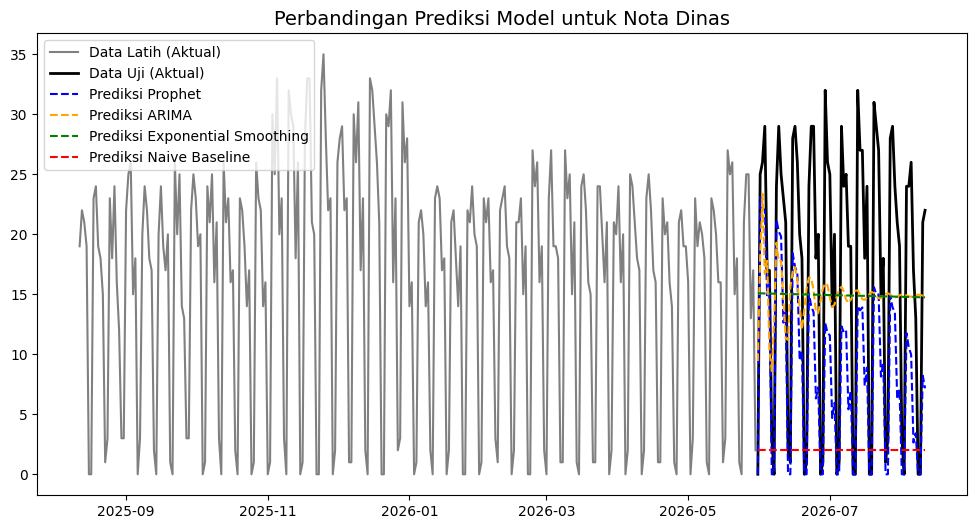

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_models():
    pegawai_id = 'a4adb04d8392abc79d52ea247fabd8348b97a78a'
    data_path = f'/content/historical_data_pegawai_{pegawai_id}.csv'

    if not os.path.exists(data_path):
        print("Jalankan cell generate data terlebih dahulu!")
        return

    df = pd.read_csv(data_path)
    df_eval = df[['tanggal', 'nodin']].rename(columns={'tanggal': 'ds', 'nodin': 'y'})
    df_eval['ds'] = pd.to_datetime(df_eval['ds'])
    df_eval = df_eval.sort_values('ds')

    train_size = int(len(df_eval) * 0.8)
    train_df = df_eval.iloc[:train_size].copy()
    test_df = df_eval.iloc[train_size:].copy()

    predictions = pd.DataFrame({'ds': test_df['ds'], 'Aktual': test_df['y']})

    print("Melatih model Prophet...")
    model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model_prophet.fit(train_df)
    future = model_prophet.make_future_dataframe(periods=len(test_df))
    pred_prophet = model_prophet.predict(future)['yhat'].iloc[-len(test_df):].values
    predictions['Prophet'] = np.maximum(0, pred_prophet)

    print("Melatih model ARIMA...")
    try:
        model_arima_fit = ARIMA(train_df['y'].values, order=(5,1,0)).fit()
        predictions['ARIMA'] = np.maximum(0, model_arima_fit.forecast(steps=len(test_df)))
    except:
        predictions['ARIMA'] = 0

    print("Melatih model Exponential Smoothing...")
    try:
        model_hw_fit = ExponentialSmoothing(train_df['y'].values, trend='add').fit()
        predictions['Exponential Smoothing'] = np.maximum(0, model_hw_fit.forecast(steps=len(test_df)))
    except:
        predictions['Exponential Smoothing'] = 0

    predictions['Naive Baseline'] = [train_df['y'].iloc[-1]] * len(test_df)

    models_to_eval = ['Prophet', 'ARIMA', 'Exponential Smoothing', 'Naive Baseline']

    print("\n--- HASIL EVALUASI MODEL ---")
    print(f"{'Model':<25} | {'MAE':<10} | {'RMSE'}")
    print("-" * 50)
    for m in models_to_eval:
        mae = mean_absolute_error(predictions['Aktual'], predictions[m])
        rmse = np.sqrt(mean_squared_error(predictions['Aktual'], predictions[m]))
        print(f"{m:<25} | {mae:<10.4f} | {rmse:.4f}")

    plt.figure(figsize=(12, 6))
    plt.plot(train_df['ds'], train_df['y'], label='Data Latih (Aktual)', color='gray')
    plt.plot(predictions['ds'], predictions['Aktual'], label='Data Uji (Aktual)', color='black', linewidth=2)
    colors = ['blue', 'orange', 'green', 'red']
    for idx, m in enumerate(models_to_eval):
        plt.plot(predictions['ds'], predictions[m], label=f'Prediksi {m}', color=colors[idx], linestyle='--')
    plt.title(f'Perbandingan Prediksi Model untuk Nota Dinas', fontsize=14)
    plt.legend()
    plt.show()

evaluate_models()